In [3]:
import numpy as np
import matplotlib.pyplot as plt
import tifffile
import os
from patchify import patchify  #Only to handle large images
import random
from scipy import ndimage
import glob
import cv2
from tqdm import tqdm
import torch
import scipy
import torch.nn as nn

In [4]:
#Useful Functions
#Used to quickly display an image
def imshow(img, title, cmap = 'gray', axis = 'off', figsize = (10, 10)):
    plt.figure(figsize= figsize)
    plt.imshow(img, cmap = cmap)
    plt.title(title)
    plt.axis(axis)
    plt.show()  

def apply_multi_gabor(gray, orientations=8, ksize=21):
    """
    Apply multiple Gabor filters to enhance line structures in various directions.
    """
    filtered_imgs = []
    for theta in np.linspace(0, np.pi, orientations, endpoint=False):
        kernel = cv2.getGaborKernel((ksize, ksize), sigma=4.0, theta=theta,
                                    lambd=10.0, gamma=0.5, psi=0, ktype=cv2.CV_32F)
        filtered = cv2.filter2D(gray, cv2.CV_8UC1, kernel)
        filtered_imgs.append(filtered)
    return np.max(filtered_imgs, axis=0)

def preprocess_web(image, visualize = False):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Step 1: Morphological tophat
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3,5))
    tophat = cv2.morphologyEx(gray, cv2.MORPH_TOPHAT, kernel)

    # Step 2: Gabor filters for radial/circular lines
    gabor_enhanced = apply_multi_gabor(tophat, orientations=12, ksize=25)

    # Step 3: CLAHE
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    results = clahe.apply(gabor_enhanced)
    #Step 4: Binarize Web
    _, edited = cv2.threshold(results, 220, 255, cv2.THRESH_BINARY) 
    #Step 5: Display Results if visualize is True
    if visualize:
        imshow(edited, title = "Results")
    #Step 6: Return preprocessed image of the web
    return edited

In [5]:
#Storing all file paths of images in a list of strings
import os
directory = r"C:\Users\adamain\Downloads\ProcessedSpiderWebs"
image_paths = []
for filename in os.listdir(directory):
    if filename.lower().endswith(".png"):
        image_paths.append(os.path.join(directory, filename))
print(image_paths)

['C:\\Users\\adamain\\Downloads\\ProcessedSpiderWebs\\cropped_19 - 1_web.png', 'C:\\Users\\adamain\\Downloads\\ProcessedSpiderWebs\\cropped_19 - 2_web.png', 'C:\\Users\\adamain\\Downloads\\ProcessedSpiderWebs\\cropped_19 - 3_web.png', 'C:\\Users\\adamain\\Downloads\\ProcessedSpiderWebs\\cropped_19 - C_web.png', 'C:\\Users\\adamain\\Downloads\\ProcessedSpiderWebs\\cropped_25 - 1_web.png', 'C:\\Users\\adamain\\Downloads\\ProcessedSpiderWebs\\cropped_25 - 2_web.png', 'C:\\Users\\adamain\\Downloads\\ProcessedSpiderWebs\\cropped_25 - 3_web.png', 'C:\\Users\\adamain\\Downloads\\ProcessedSpiderWebs\\cropped_25 - C_web.png', 'C:\\Users\\adamain\\Downloads\\ProcessedSpiderWebs\\cropped_26 - 1_web.png', 'C:\\Users\\adamain\\Downloads\\ProcessedSpiderWebs\\cropped_26 - 2_web.png', 'C:\\Users\\adamain\\Downloads\\ProcessedSpiderWebs\\cropped_26 - 3_web.png', 'C:\\Users\\adamain\\Downloads\\ProcessedSpiderWebs\\cropped_26 - 4_web.png', 'C:\\Users\\adamain\\Downloads\\ProcessedSpiderWebs\\cropped_26

In [6]:
#Preprocess All Images
preprocessed_images = []
for path in image_paths:
    image = cv2.imread(path)
    preprocessed_images.append(preprocess_web(image))



In [7]:
#Get center coordinates of web hub for all images
coordinates = []
with open("web_centers.txt", "r") as f:
    for line in f:
        x, y = map(int, line.strip().split(","))
        coordinates.append((x, y))


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from typing import Tuple, List
import math
import scipy.signal


class SpiderWebAnalyzer:
    def __init__(self, image_path: str = None, image: np.ndarray = None):
        if image is not None:
            self.image = image
        elif image_path is not None:
            self.image = cv2.imread(image_path)
            if self.image is None:
                raise ValueError(f"Could not load image from {image_path}")
        else:
            raise ValueError("Either image_path or image must be provided")

        self.image_rgb = cv2.cvtColor(self.image, cv2.COLOR_GRAY2RGB)
        self.image_gray = self.image
        self.image = cv2.cvtColor(self.image_gray, cv2.COLOR_GRAY2BGR)
        self.center = None
        self.radius = None

    def set_center_and_radius(self, center: Tuple[int, int], radius: int):
        self.center = center
        self.radius = radius

    def detect_center_interactive(self):
        def mouse_callback(event, x, y, flags, param):
            if event == cv2.EVENT_LBUTTONDOWN:
                self.center = (x, y)
                print(f"Center set to: ({x}, {y})")

        cv2.namedWindow('Click Center Point', cv2.WINDOW_NORMAL)
        cv2.setMouseCallback('Click Center Point', mouse_callback)

        temp_image = self.image.copy()
        cv2.imshow('Click Center Point', temp_image)

        print("Click on the center of the spider web hub, then press any key...")
        cv2.waitKey(0)
        cv2.destroyAllWindows()

        if self.center is None:
            raise ValueError("No center point was selected")

    def create_radial_lines(self, line_length: int = None) -> List[Tuple[np.ndarray, np.ndarray]]:
        if self.center is None:
            raise ValueError("Center point must be set first")

        if line_length is None:
            line_length = self.radius if self.radius else min(self.image.shape[:2]) // 2

        lines = []
        center_x, center_y = self.center

        for angle_deg in range(360):
            angle_rad = math.radians(angle_deg)
            end_x = int(center_x + line_length * math.cos(angle_rad))
            end_y = int(center_y + line_length * math.sin(angle_rad))
            x_coords, y_coords = self._bresenham_line(center_x, center_y, end_x, end_y)
            lines.append((x_coords, y_coords))

        return lines

    def _bresenham_line(self, x0: int, y0: int, x1: int, y1: int) -> Tuple[np.ndarray, np.ndarray]:
        dx = abs(x1 - x0)
        dy = abs(y1 - y0)
        sx = 1 if x0 < x1 else -1
        sy = 1 if y0 < y1 else -1
        err = dx - dy

        x_coords, y_coords = [], []
        x, y = x0, y0

        while True:
            x_coords.append(x)
            y_coords.append(y)
            if x == x1 and y == y1:
                break
            e2 = 2 * err
            if e2 > -dy:
                err -= dy
                x += sx
            if e2 < dx:
                err += dx
                y += sy

        return np.array(x_coords), np.array(y_coords)

    def score_lines_by_white_pixels(self, lines: List[Tuple[np.ndarray, np.ndarray]], white_threshold: int = 240) -> List[int]:
        scores = []
        height, width = self.image_gray.shape

        for x_coords, y_coords in lines:
            valid_mask = (x_coords >= 0) & (x_coords < width) & (y_coords >= 0) & (y_coords < height)
            valid_x = x_coords[valid_mask]
            valid_y = y_coords[valid_mask]
            if len(valid_x) > 0:
                pixel_values = self.image_gray[valid_y, valid_x]
                white_count = np.sum(pixel_values >= white_threshold)
                scores.append(white_count)
            else:
                scores.append(0)

        return scores

    def find_peak_lines(self, scores: List[int], min_height: int = 50) -> List[int]:
        peaks, _ = scipy.signal.find_peaks(scores, height=min_height)
        return peaks.tolist()

    def filter_peaks_by_angle(self, peak_indices: List[int], scores: List[int], angle_thresh: int = 5) -> List[int]:
        if not peak_indices:
            return []

        sorted_peaks = sorted(peak_indices)
        filtered_peaks = []
        current_cluster = [sorted_peaks[0]]

        for i in range(1, len(sorted_peaks)):
            if sorted_peaks[i] - sorted_peaks[i - 1] <= angle_thresh:
                current_cluster.append(sorted_peaks[i])
            else:
                best_peak = max(current_cluster, key=lambda idx: scores[idx])
                filtered_peaks.append(best_peak)
                current_cluster = [sorted_peaks[i]]

        if current_cluster:
            best_peak = max(current_cluster, key=lambda idx: scores[idx])
            filtered_peaks.append(best_peak)

        return filtered_peaks

    def visualize_analysis(self, lines: List[Tuple[np.ndarray, np.ndarray]], scores: List[int],
                           show_all_lines: bool = False, show_top_n: int = 10,
                           highlight_peaks: bool = False, min_height: int = 50,
                           angle_filter_deg: int = 5):
        fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))

        ax1.imshow(self.image_rgb)
        ax1.set_title('Original Image')
        ax1.axis('off')

        ax2.imshow(self.image_rgb)
        if self.center:
            ax2.plot(self.center[0], self.center[1], 'ro', markersize=8, label='Center')
        if self.radius and self.center:
            circle = plt.Circle(self.center, self.radius, fill=False, color='green', linewidth=2)
            ax2.add_patch(circle)
        ax2.set_title('Center and Analysis Circle')
        ax2.legend()
        ax2.axis('off')

        ax3.imshow(self.image_rgb)
        if self.center:
            ax3.plot(self.center[0], self.center[1], 'ro', markersize=8)

        if lines and scores:
            if highlight_peaks:
                peak_indices = self.find_peak_lines(scores, min_height=min_height)
                peak_indices = self.filter_peaks_by_angle(peak_indices, scores, angle_thresh=angle_filter_deg)
                for i in peak_indices:
                    x_coords, y_coords = lines[i]
                    ax3.plot(x_coords, y_coords, 'b-', linewidth=2, alpha=0.8)
            else:
                top_indices = np.argsort(scores)[-show_top_n:]
                for i in top_indices:
                    x_coords, y_coords = lines[i]
                    ax3.plot(x_coords, y_coords, 'r-', linewidth=1, alpha=0.7)

        if show_all_lines and lines:
            for x_coords, y_coords in lines:
                ax3.plot(x_coords, y_coords, 'gray', linewidth=0.5, alpha=0.3)

        ax3.set_title('Radial Lines Highlighted')
        ax3.axis('off')

        ax4.bar(range(len(scores)), scores, alpha=0.7)
        ax4.set_title('White Pixel Scores by Angle')
        ax4.set_xlabel('Angle (degrees)')
        ax4.set_ylabel('White Pixel Count')

        if highlight_peaks:
            peak_indices = self.find_peak_lines(scores, min_height=min_height)
            peak_indices = self.filter_peaks_by_angle(peak_indices, scores, angle_thresh=angle_filter_deg)
            for i in peak_indices:
                ax4.bar(i, scores[i], color='blue', alpha=0.9)
            ax4.axhline(min_height, color='red', linestyle='--', label='Min Brightness Threshold')
            ax4.legend()
        else:
            top_indices = np.argsort(scores)[-show_top_n:]
            for i in top_indices:
                ax4.bar(i, scores[i], color='red', alpha=0.8)

        plt.tight_layout()
        plt.show()

    def get_analysis_stats(self, scores: List[int]) -> dict:
        if not scores:
            return {}

        scores_array = np.array(scores)

        stats = {
            'total_lines': len(scores),
            'mean_score': np.mean(scores_array),
            'median_score': np.median(scores_array),
            'std_score': np.std(scores_array),
            'min_score': np.min(scores_array),
            'max_score': np.max(scores_array),
            'top_10_angles': np.argsort(scores_array)[-10:].tolist(),
            'top_10_scores': sorted(scores_array)[-10:]
        }

        return stats
    def draw_lines_on_image(self, lines: List[Tuple[np.ndarray, np.ndarray]], color=(0, 0, 255), thickness=1) -> np.ndarray:
        """
        Draws the given lines on a copy of the original image.

        Args:
            lines: List of (x_coords, y_coords) tuples
            color: BGR color of the lines
            thickness: Line thickness

        Returns:
            Image with lines drawn (as a NumPy array)
        """
        image_copy = self.image.copy()
        for x_coords, y_coords in lines:
            for i in range(1, len(x_coords)):
                pt1 = (int(x_coords[i - 1]), int(y_coords[i - 1]))
                pt2 = (int(x_coords[i]), int(y_coords[i]))
                cv2.line(image_copy, pt1, pt2, color, thickness)
        return image_copy
#More robust usage function running many trials
import matplotlib.pyplot as plt

import cv2
import numpy as np
import matplotlib.pyplot as plt
from typing import List, Tuple

import matplotlib.pyplot as plt
import numpy as np
from typing import Tuple, List
import matplotlib.pyplot as plt
import numpy as np
from typing import Tuple, List
import cv2
import math

def circular_mean_deg(angles_deg: List[float], weights: List[float]) -> float:
    """
    Compute weighted circular mean of angles in degrees.
    """
    angles_rad = np.deg2rad(angles_deg)
    sin_sum = np.sum(np.sin(angles_rad) * weights)
    cos_sum = np.sum(np.cos(angles_rad) * weights)
    mean_angle_rad = math.atan2(sin_sum, cos_sum)
    mean_angle_deg = np.rad2deg(mean_angle_rad) % 360
    return mean_angle_deg

def robust_spider_web_analysis(image: np.ndarray,
                               center: Tuple[int, int],
                               radii: List[int],
                               white_threshold: int = 240,
                               peak_min_height: int = 50,
                               angle_filter_deg: int = 5,
                               vote_threshold: float = 100,  # tune after weighting
                               show_debug: bool = True) -> Tuple[List[float], List[Tuple[np.ndarray, np.ndarray]], np.ndarray]:
    """
    Spider web radial line detection with weighted voting and refined clustering using weighted circular mean.

    Args:
        image: Input BGR image as a NumPy array
        center: (x, y) center of the web
        radii: List of radii to try
        white_threshold: Threshold for white pixel detection
        peak_min_height: Minimum white pixel score to consider a peak
        angle_filter_deg: Angular tolerance for clustering (± degrees)
        vote_threshold: Minimum sum of scores in angle bin to be accepted
        show_debug: Show plots if True

    Returns:
        final_angles: List of refined stable angles (float degrees)
        final_lines: List of line coordinates (x_coords, y_coords)
        output_image: Image with stable lines drawn
    """

    angle_bins = [[] for _ in range(360)]
    # Store best scoring line and score per bin: {bin_angle: (line, score, raw_angle)}
    angle_to_lines = {}

    for radius in radii:
        analyzer = SpiderWebAnalyzer(image=image)
        analyzer.set_center_and_radius(center, radius)
        lines = analyzer.create_radial_lines()
        scores = analyzer.score_lines_by_white_pixels(lines, white_threshold=white_threshold)
        raw_peaks = analyzer.find_peak_lines(scores, min_height=peak_min_height)
        filtered_peaks = analyzer.filter_peaks_by_angle(raw_peaks, scores, angle_thresh=angle_filter_deg)

        for angle in filtered_peaks:
            score_at_angle = scores[angle]
            for delta in range(-angle_filter_deg, angle_filter_deg + 1):
                bin_angle = (angle + delta) % 360
                angle_bins[bin_angle].append((angle, lines[angle], score_at_angle))
                # Store or update best scoring line per bin
                if (bin_angle not in angle_to_lines) or (score_at_angle > angle_to_lines[bin_angle][1]):
                    angle_to_lines[bin_angle] = (lines[angle], score_at_angle, angle)

    # Weighted vote sums per angle bin
    vote_counts = [sum(entry[2] for entry in bin) for bin in angle_bins]

    # Angles passing vote threshold
    raw_stable_angles = [i for i, count in enumerate(vote_counts) if count >= vote_threshold]

    used_angles = set()
    final_angles = []
    final_lines = []

    # Cluster raw stable angles with ±angle_filter_deg and compute weighted circular mean
    for angle in raw_stable_angles:
        if angle in used_angles:
            continue

        cluster = [(a % 360) for a in range(angle - angle_filter_deg, angle + angle_filter_deg + 1)]
        cluster = [a for a in cluster if a in raw_stable_angles]

        # Collect all cluster entries with their scores and raw detected angles
        cluster_entries = []
        for a in cluster:
            if a in angle_to_lines:
                line, score, raw_angle = angle_to_lines[a]
                cluster_entries.append((a, line, score, raw_angle))

        if not cluster_entries:
            continue

        # Weighted circular mean of raw detected angles, weights = scores
        angles_for_mean = [entry[3] for entry in cluster_entries]
        scores_for_mean = [entry[2] for entry in cluster_entries]
        refined_angle = circular_mean_deg(angles_for_mean, scores_for_mean)

        # Select line with highest score in cluster to draw
        best_entry = max(cluster_entries, key=lambda e: e[2])
        best_line = best_entry[1]

        final_angles.append(refined_angle)
        final_lines.append(best_line)
        used_angles.update(cluster)

    # Draw final lines on image
    final_analyzer = SpiderWebAnalyzer(image=image)
    output_image = final_analyzer.draw_lines_on_image(final_lines, color=(0, 0, 255), thickness=2)

    if show_debug:
        fig, axs = plt.subplots(1, 2, figsize=(16, 6))

        axs[0].imshow(cv2.cvtColor(output_image, cv2.COLOR_BGR2RGB))
        axs[0].set_title("Stable Radial Lines (Drawn on Image)")
        axs[0].axis("off")

        axs[1].bar(range(360), vote_counts, color='gray')
        axs[1].set_title("Angle Vote Histogram (Weighted Sum of Scores, ±{}° tolerance)".format(angle_filter_deg))
        axs[1].set_xlabel("Angle (degrees)")
        axs[1].set_ylabel("Weighted Vote Sum")

        for angle in final_angles:
            axs[1].bar(int(round(angle)) % 360, vote_counts[int(round(angle)) % 360], color='green')

        plt.tight_layout()
        plt.show()

    return final_angles, final_lines, output_image





In [40]:
test = [preprocessed_images[8]]

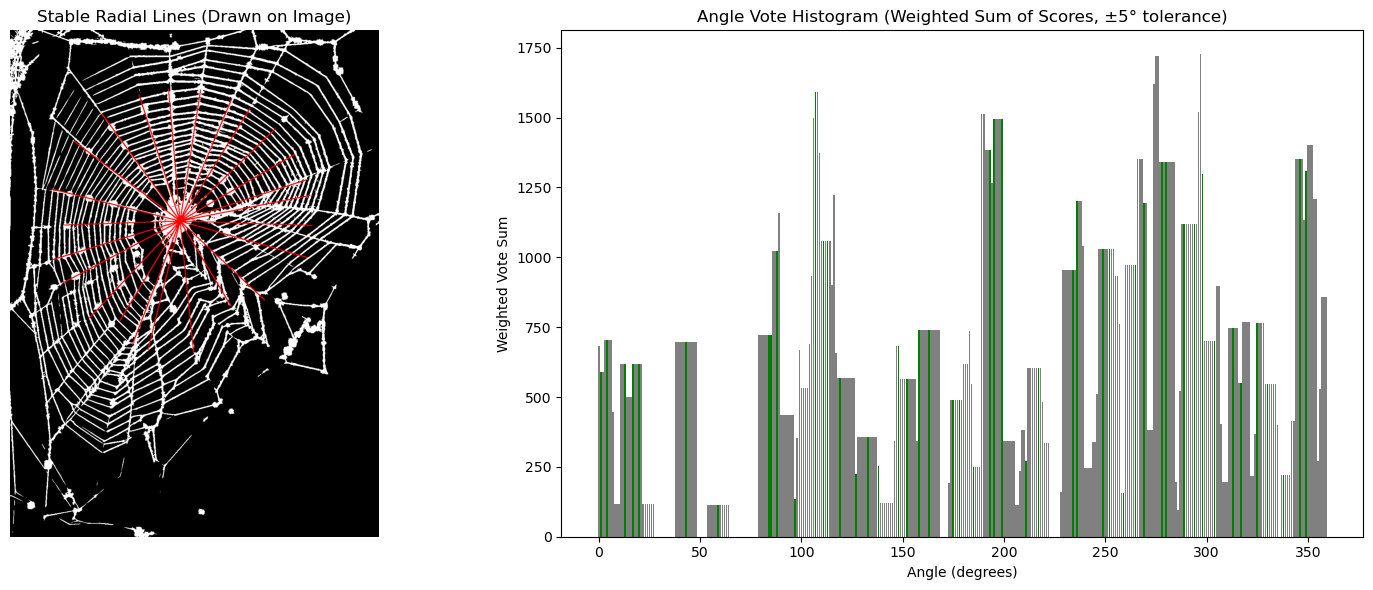

0
C:\Users\adamain\Downloads\ProcessedSpiderWebs\cropped_26 - 1_web.png


In [ ]:
radii = [100, 200, 300, 350, 400]
for image in test:
    angles, lines, line_img = robust_spider_web_analysis(
    image = image,
    radii = radii,
    center=(coordinates[8][0], coordinates[8][1]),
    peak_min_height=90
)
    print(image_paths[8])


In [61]:
import numpy as np
import cv2
from scipy import ndimage
from scipy.spatial import ConvexHull
import matplotlib.pyplot as plt
from skimage.measure import profile_line
from skimage.morphology import skeletonize
from sklearn.cluster import DBSCAN

def find_radial_transition_points(binary_image, hub_center, num_radials=64, max_radius=None, adaptive_radius=True):
    """
    Enhanced version that uses more radial lines and adaptive radius detection.
    """
    h, w = binary_image.shape
    if max_radius is None:
        max_radius = int(np.sqrt(h**2 + w**2) / 2)
    
    hub_x, hub_y = hub_center
    transition_points = []
    radial_angles = []
    transition_distances = []
    
    # Use more radial lines for better coverage
    angles = np.linspace(0, 2*np.pi, num_radials, endpoint=False)
    
    for angle in angles:
        # Calculate end point of radial line
        end_x = hub_x + max_radius * np.cos(angle)
        end_y = hub_y + max_radius * np.sin(angle)
        
        # Get intensity profile along this radial line
        profile = profile_line(binary_image, (hub_y, hub_x), (end_y, end_x))
        
        # Find transition point with enhanced detection
        transition_result = find_hub_to_circle_transition_enhanced(
            profile, hub_center, angle, max_radius, binary_image
        )
        
        if transition_result is not None:
            transition_point, distance = transition_result
            transition_points.append(transition_point)
            radial_angles.append(angle)
            transition_distances.append(distance)
    
    return transition_points, radial_angles, transition_distances

def find_hub_to_circle_transition_enhanced(intensity_profile, hub_center, angle, max_radius, binary_image):
    """
    Enhanced transition detection that better handles irregular black regions.
    """
    hub_x, hub_y = hub_center
    
    # Light smoothing
    smoothed = ndimage.gaussian_filter1d(intensity_profile, sigma=1.5)
    
    # More flexible bounds - allow for larger black regions
    min_hub_radius = max_radius * 0.05  # Start very close to hub
    max_hub_radius = max_radius * 0.6   # Allow for larger black regions
    
    # Convert to indices
    min_idx = int((min_hub_radius / max_radius) * len(smoothed))
    max_idx = int((max_hub_radius / max_radius) * len(smoothed))
    
    # Strategy 1: Look for the first substantial white region after dark area
    # Use adaptive thresholding based on local statistics
    for i in range(min_idx, min(max_idx, len(smoothed) - 8)):
        # Look ahead for a substantial white region
        white_region = smoothed[i:i+8]
        
        # Adaptive threshold based on local context
        local_mean = np.mean(smoothed[max(0, i-20):i+20])
        local_std = np.std(smoothed[max(0, i-20):i+20])
        adaptive_threshold = local_mean + 0.5 * local_std
        
        if np.mean(white_region) > adaptive_threshold and len(white_region) > 4:
            # Check if this is a significant transition from darker region
            if i > 15:
                preceding_region = smoothed[max(0, i-15):i]
                if np.mean(preceding_region) < np.mean(white_region) * 0.6:
                    radius_at_transition = (i / len(intensity_profile)) * max_radius
                    actual_x = hub_x + radius_at_transition * np.cos(angle)
                    actual_y = hub_y + radius_at_transition * np.sin(angle)
                    return (actual_x, actual_y), radius_at_transition
    
    # Strategy 2: Look for sustained positive gradient
    gradient = np.gradient(smoothed)
    
    # Find areas of sustained positive gradient
    for i in range(min_idx, min(max_idx, len(gradient) - 5)):
        if gradient[i] > np.std(gradient) * 0.6:
            # Check for sustained positive trend
            next_region = gradient[i:i+5]
            if np.mean(next_region) > 0 and np.sum(next_region > 0) >= 3:
                radius_at_transition = (i / len(intensity_profile)) * max_radius
                actual_x = hub_x + radius_at_transition * np.cos(angle)
                actual_y = hub_y + radius_at_transition * np.sin(angle)
                return (actual_x, actual_y), radius_at_transition
    
    # Strategy 3: Find the last significant dark region
    # This helps capture irregular black areas
    for i in range(max_idx, min_idx, -1):  # Search backwards
        if i < len(smoothed) and smoothed[i] < np.mean(smoothed) * 0.7:
            # Found a dark region, look for its end
            for j in range(i, min(len(smoothed), i + 20)):
                if smoothed[j] > np.mean(smoothed):
                    radius_at_transition = (j / len(intensity_profile)) * max_radius
                    actual_x = hub_x + radius_at_transition * np.cos(angle)
                    actual_y = hub_y + radius_at_transition * np.sin(angle)
                    return (actual_x, actual_y), radius_at_transition
    
    # Fallback: adaptive radius based on image content
    fallback_radius = max_radius * 0.25
    actual_x = hub_x + fallback_radius * np.cos(angle)
    actual_y = hub_y + fallback_radius * np.sin(angle)
    return (actual_x, actual_y), fallback_radius

def create_hub_polygon_enhanced(transition_points, radial_angles, transition_distances, 
                               hub_center, smoothing_factor=0.2):
    """
    Enhanced polygon creation that better handles irregular shapes and outliers.
    """
    if len(transition_points) < 4:
        # Fallback to circular approximation
        hub_x, hub_y = hub_center
        radius = 50
        angles = np.linspace(0, 2*np.pi, 16, endpoint=False)
        polygon_points = [(hub_x + radius * np.cos(a), hub_y + radius * np.sin(a)) 
                         for a in angles]
        return np.array(polygon_points), create_polygon_dict(polygon_points, hub_center)
    
    points = np.array(transition_points)
    distances = np.array(transition_distances)
    angles = np.array(radial_angles)
    
    # Enhanced outlier removal using clustering
    points_clean, distances_clean, angles_clean = remove_outliers_enhanced(
        points, distances, angles, hub_center
    )
    
    if len(points_clean) < 4:
        # Use median-based circular approximation
        median_dist = np.median(distances) if len(distances) > 0 else 50
        hub_x, hub_y = hub_center
        angles_uniform = np.linspace(0, 2*np.pi, 16, endpoint=False)
        polygon_points = [(hub_x + median_dist * np.cos(a), hub_y + median_dist * np.sin(a)) 
                         for a in angles_uniform]
        return np.array(polygon_points), create_polygon_dict(polygon_points, hub_center)
    
    # Create polygon with better handling of irregular shapes
    polygon_points = create_irregular_polygon(points_clean, distances_clean, angles_clean, 
                                            hub_center, smoothing_factor)
    
    polygon_dict = create_polygon_dict(polygon_points, hub_center)
    polygon_dict['transition_distances'] = distances_clean
    polygon_dict['radial_angles'] = angles_clean
    
    return polygon_points, polygon_dict

def remove_outliers_enhanced(points, distances, angles, hub_center):
    """
    Enhanced outlier removal that preserves the natural shape variation.
    """
    hub_x, hub_y = hub_center
    
    # Method 1: Remove extreme outliers using IQR
    Q1 = np.percentile(distances, 25)
    Q3 = np.percentile(distances, 75)
    IQR = Q3 - Q1
    
    # More generous outlier bounds to preserve natural variation
    lower_bound = Q1 - 2.0 * IQR
    upper_bound = Q3 + 2.0 * IQR
    
    # Remove only extreme outliers
    valid_indices = (distances >= lower_bound) & (distances <= upper_bound)
    
    # Method 2: Use DBSCAN clustering to identify the main cluster
    if len(points) > 10:
        # Normalize points for clustering
        points_normalized = (points - np.mean(points, axis=0)) / np.std(points, axis=0)
        
        # Clustering to find main group
        clustering = DBSCAN(eps=1.2, min_samples=3).fit(points_normalized)
        
        # Find the largest cluster (main hub region)
        labels = clustering.labels_
        unique_labels, counts = np.unique(labels[labels >= 0], return_counts=True)
        
        if len(unique_labels) > 0:
            main_cluster_label = unique_labels[np.argmax(counts)]
            cluster_valid = labels == main_cluster_label
            
            # Combine both filtering methods
            valid_indices = valid_indices & cluster_valid
    
    # Ensure we have enough points
    if np.sum(valid_indices) < 4:
        # If too aggressive, use just the IQR method
        valid_indices = (distances >= lower_bound) & (distances <= upper_bound)
    
    return points[valid_indices], distances[valid_indices], angles[valid_indices]

def create_irregular_polygon(points, distances, angles, hub_center, smoothing_factor):
    """
    Create a polygon that better follows the irregular shape of the hub region.
    """
    hub_x, hub_y = hub_center
    
    # Sort points by angle to ensure proper polygon ordering
    sorted_indices = np.argsort(angles)
    points_sorted = points[sorted_indices]
    distances_sorted = distances[sorted_indices]
    angles_sorted = angles[sorted_indices]
    
    # Option 1: Use the points as-is with minimal smoothing
    if smoothing_factor <= 0.1:
        # Ensure we have a valid convex hull
        if len(points_sorted) > 2:
            hull = ConvexHull(points_sorted)
            return points_sorted[hull.vertices]
        else:
            return points_sorted
    
    # Option 2: Apply controlled smoothing while preserving irregular shape
    # Create a smooth distance profile
    angles_interp = np.linspace(0, 2*np.pi, len(angles_sorted) * 2, endpoint=False)
    
    # Interpolate distances smoothly
    distances_interp = np.interp(angles_interp, angles_sorted, distances_sorted)
    
    # Apply light smoothing to the distance profile
    distances_smooth = ndimage.gaussian_filter1d(distances_interp, sigma=smoothing_factor * 10)
    
    # Convert back to cartesian coordinates
    smooth_points = np.array([
        [hub_x + d * np.cos(a), hub_y + d * np.sin(a)]
        for d, a in zip(distances_smooth, angles_interp)
    ])
    
    # Create convex hull for the final polygon
    if len(smooth_points) > 2:
        hull = ConvexHull(smooth_points)
        return smooth_points[hull.vertices]
    else:
        return smooth_points

def create_polygon_dict(polygon_points, hub_center):
    """Helper function to create polygon dictionary."""
    return {
        'points': polygon_points.tolist() if isinstance(polygon_points, np.ndarray) else polygon_points,
        'hub_center': hub_center,
        'num_vertices': len(polygon_points),
        'creation_method': 'enhanced_irregular_detection'
    }

def visualize_hub_detection_enhanced(binary_image, hub_center, transition_points, 
                                   polygon_points, transition_distances=None):
    """
    Enhanced visualization showing the detection process.
    """
    fig, axes = plt.subplots(2, 2, figsize=(20, 16))
    
    # Original image with transition points
    axes[0,0].imshow(binary_image, cmap='gray')
    axes[0,0].scatter(*hub_center, color='red', s=100, marker='x', label='Hub Center')
    
    if transition_points:
        trans_x, trans_y = zip(*transition_points)
        # Color code points by distance if available
        if transition_distances is not None:
            scatter = axes[0,0].scatter(trans_x, trans_y, c=transition_distances, 
                                      s=30, alpha=0.7, cmap='viridis', label='Transition Points')
            plt.colorbar(scatter, ax=axes[0,0], label='Distance from Hub')
        else:
            axes[0,0].scatter(trans_x, trans_y, color='blue', s=30, alpha=0.7, label='Transition Points')
    
    axes[0,0].set_title('Detected Transition Points')
    axes[0,0].legend()
    axes[0,0].axis('off')
    
    # Image with polygon overlay
    axes[0,1].imshow(binary_image, cmap='gray')
    axes[0,1].scatter(*hub_center, color='red', s=100, marker='x', label='Hub Center')
    
    if len(polygon_points) > 0:
        poly_closed = np.vstack([polygon_points, polygon_points[0]])
        axes[0,1].plot(poly_closed[:, 0], poly_closed[:, 1], 'g-', linewidth=2, label='Hub Polygon')
        axes[0,1].fill(poly_closed[:, 0], poly_closed[:, 1], 'green', alpha=0.3)
    
    axes[0,1].set_title('Hub Polygon')
    axes[0,1].legend()
    axes[0,1].axis('off')
    
    # Distance histogram
    if transition_distances is not None:
        axes[1,0].hist(transition_distances, bins=20, alpha=0.7, color='blue')
        axes[1,0].axvline(np.mean(transition_distances), color='red', linestyle='--', 
                         label=f'Mean: {np.mean(transition_distances):.1f}')
        axes[1,0].axvline(np.median(transition_distances), color='green', linestyle='--', 
                         label=f'Median: {np.median(transition_distances):.1f}')
        axes[1,0].set_xlabel('Distance from Hub')
        axes[1,0].set_ylabel('Frequency')
        axes[1,0].set_title('Distribution of Transition Distances')
        axes[1,0].legend()
    
    # Polar plot of transition points
    if transition_points and transition_distances is not None:
        # Calculate angles from hub center
        hub_x, hub_y = hub_center
        angles = [np.arctan2(y - hub_y, x - hub_x) for x, y in transition_points]
        
        ax_polar = plt.subplot(2, 2, 4, projection='polar')
        ax_polar.scatter(angles, transition_distances, c='blue', alpha=0.7)
        ax_polar.set_title('Polar View of Transition Points')
        ax_polar.set_ylim(0, max(transition_distances) * 1.1)
    
    plt.tight_layout()
    plt.show()

def process_spider_web_enhanced(binary_image, hub_center, num_radials=64, 
                               smoothing_factor=0.2, visualize=True):
    """
    Enhanced spider web processing pipeline that better handles irregular shapes.
    """
    print(f"Processing spider web with hub at {hub_center}")
    print(f"Using {num_radials} radial lines for analysis")
    
    # Find transition points with enhanced detection
    transition_points, radial_angles, transition_distances = find_radial_transition_points(
        binary_image, hub_center, num_radials, adaptive_radius=True
    )
    
    print(f"Found {len(transition_points)} transition points")
    print(f"Distance range: {np.min(transition_distances):.1f} - {np.max(transition_distances):.1f}")
    
    # Create enhanced polygon
    polygon_points, polygon_dict = create_hub_polygon_enhanced(
        transition_points, radial_angles, transition_distances, hub_center, smoothing_factor
    )
    
    if visualize:
        visualize_hub_detection_enhanced(binary_image, hub_center, transition_points, 
                                       polygon_points, transition_distances)
    
    return polygon_dict

# Example usage:
# polygon_dict = process_spider_web_enhanced(binary_image, hub_center, num_radials=64, smoothing_factor=0.2)

Processing spider web 1
Processing spider web with hub at (447, 400)
Using 64 radial lines for analysis
Found 64 transition points
Distance range: 34.0 - 236.3


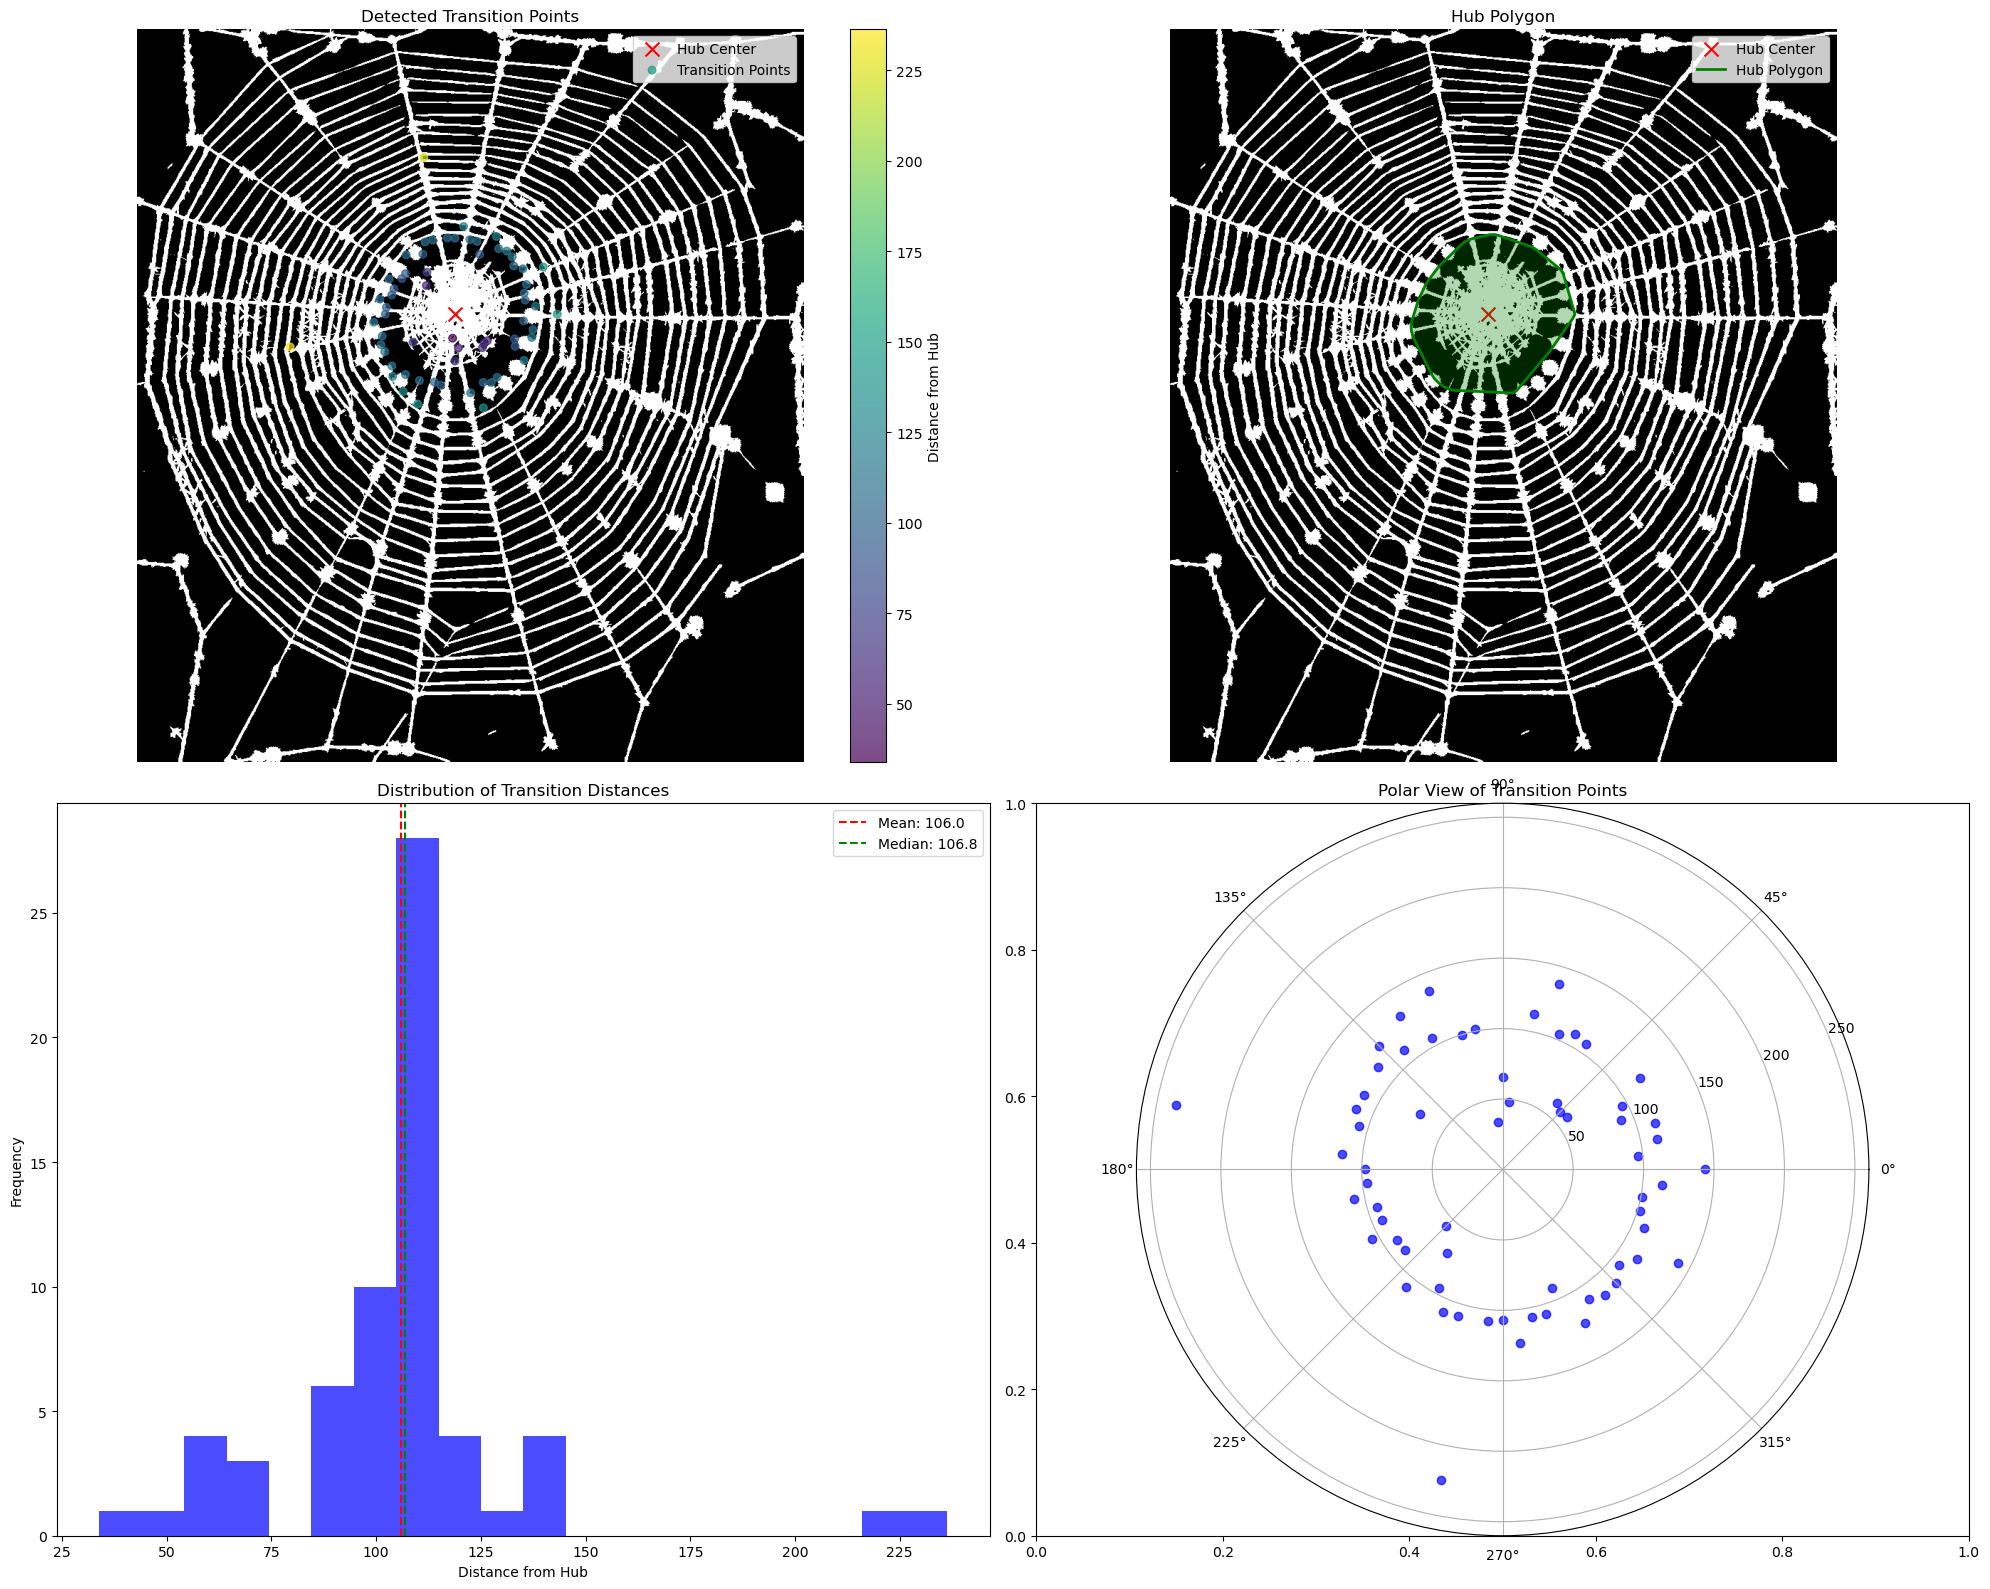

Processing spider web 2
Processing spider web with hub at (513, 576)
Using 64 radial lines for analysis
Found 64 transition points
Distance range: 48.9 - 210.8


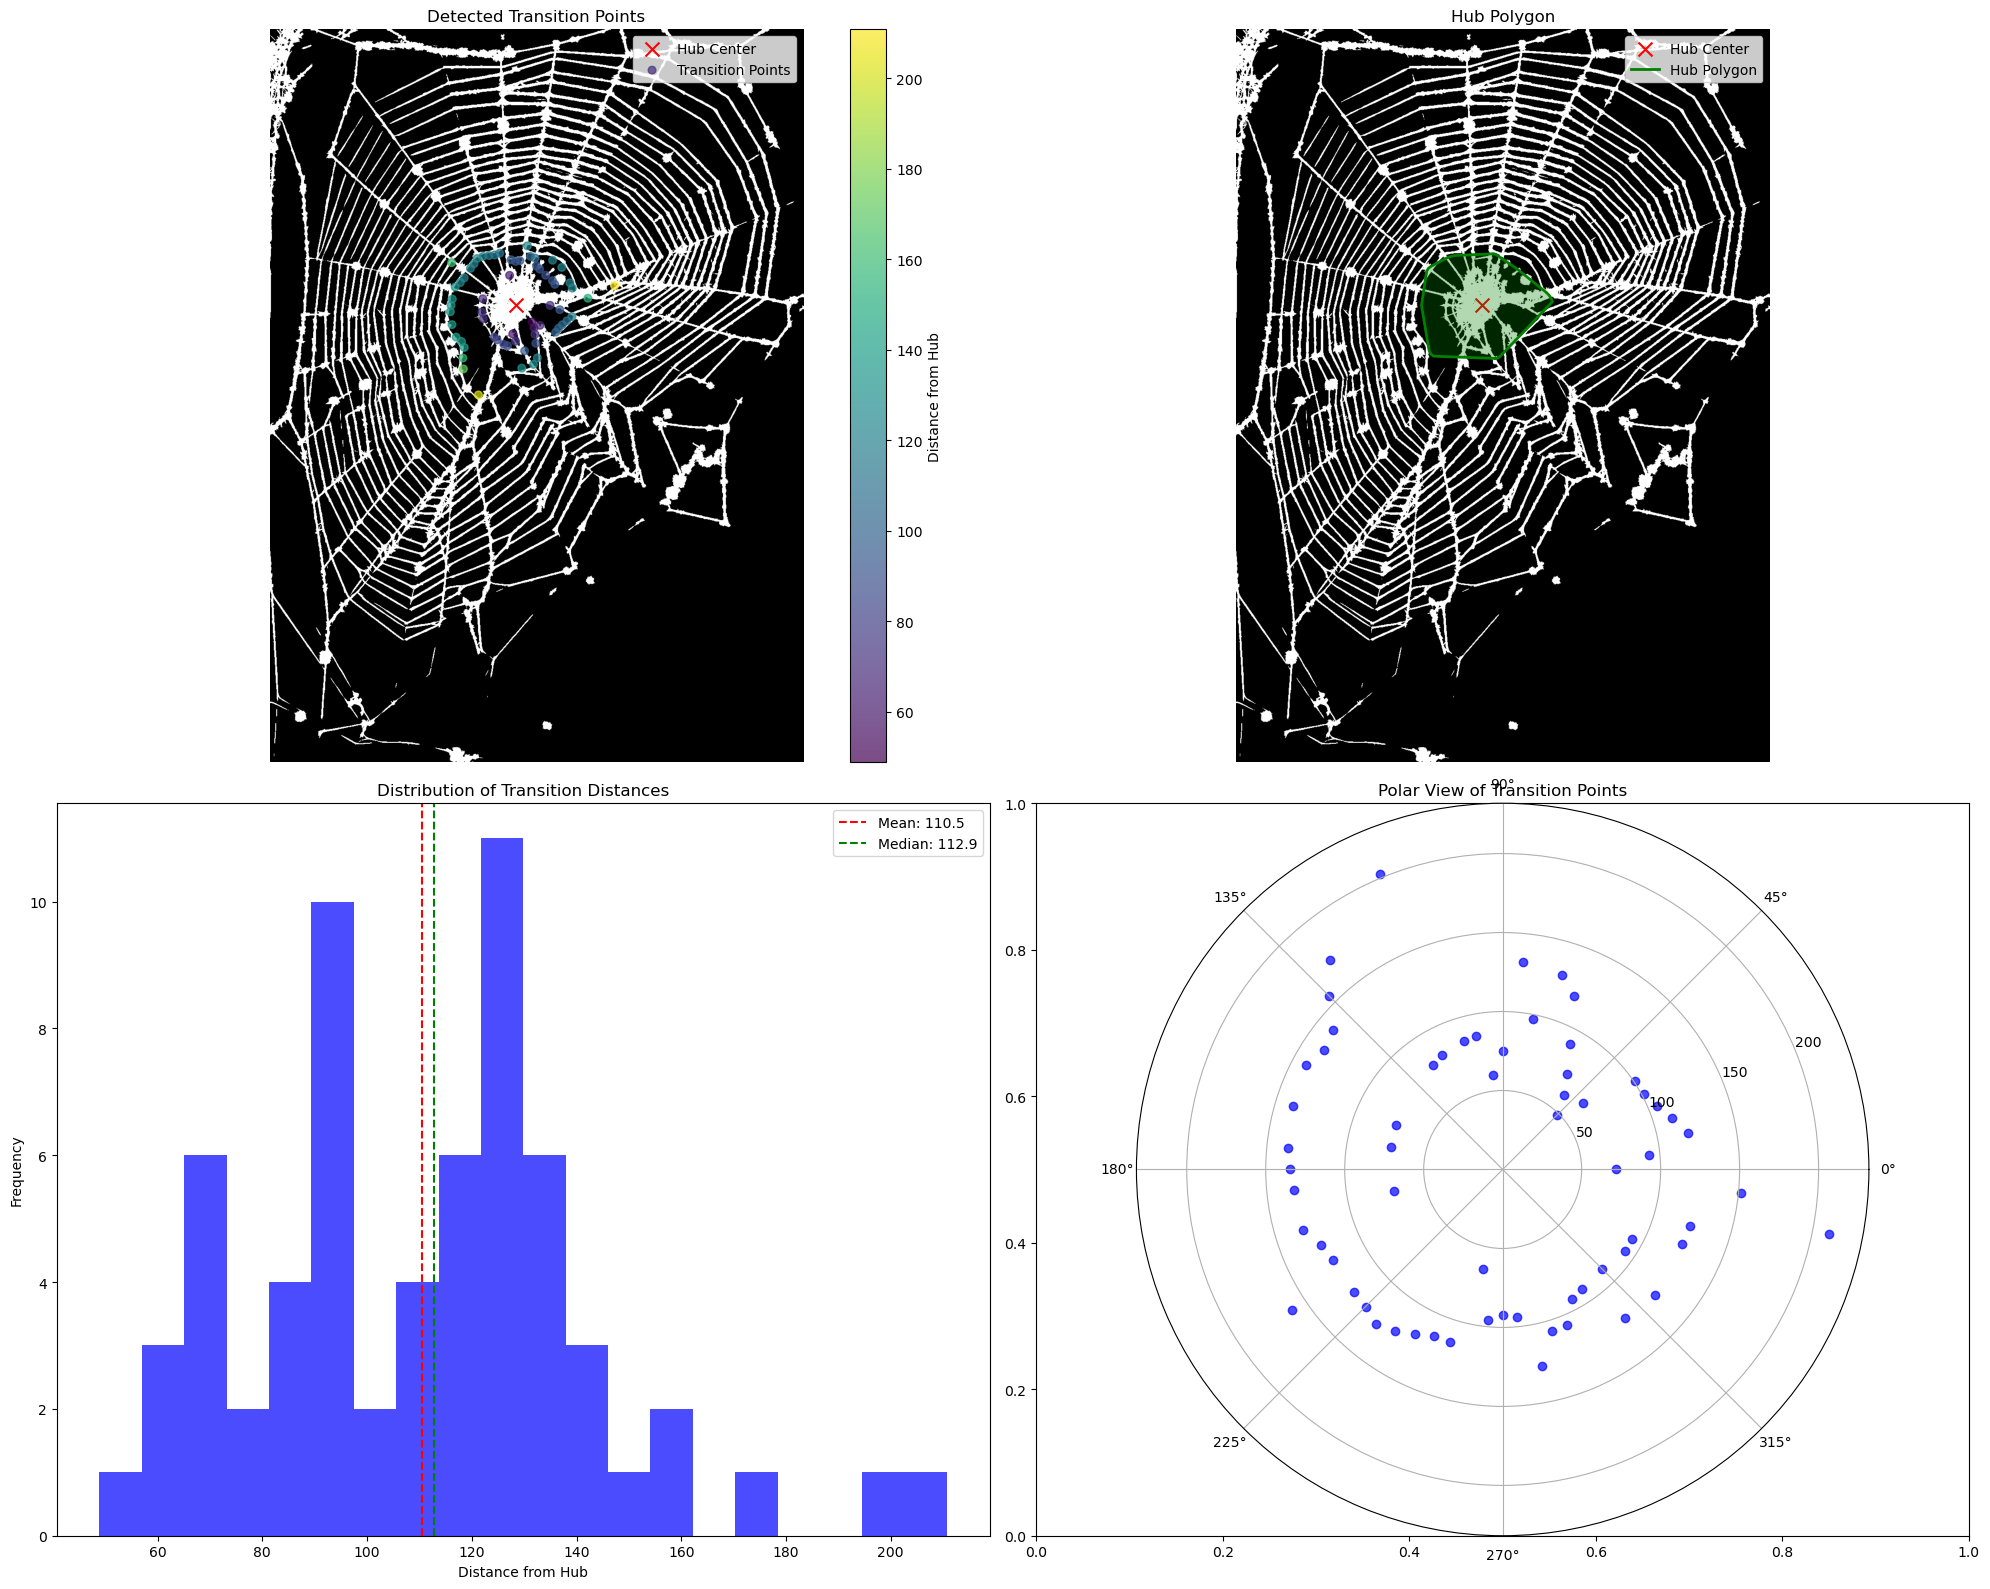

In [62]:

# Example usage:

    # This is how you would use it with your data:
 
    # Assuming you have:
    # - spider_web_images: list of binarized images
    # - hub_centers: list of (x, y) coordinates
    
hub_polygons = []
ex_images = [preprocessed_images[0], preprocessed_images[8]]
hub_centers = [coordinates[0], coordinates[8]]
for i, (image, hub_center) in enumerate(zip(ex_images, hub_centers)):
    print(f"Processing spider web {i+1}")
    polygon_dict = process_spider_web_enhanced(image, hub_center, visualize=True)
    hub_polygons.append(polygon_dict)
    
